<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/capstone_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

# Load the dataset with a different encoding
try:
    df = pd.read_csv('/content/FloridaBikeRentals.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('/content/FloridaBikeRentals.csv', encoding='latin1')

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Checking for Null Values

In [6]:
print("Number of null values per column:")
display(df.isnull().sum())

Number of null values per column:


,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


### Checking correlation of features using a heatmap

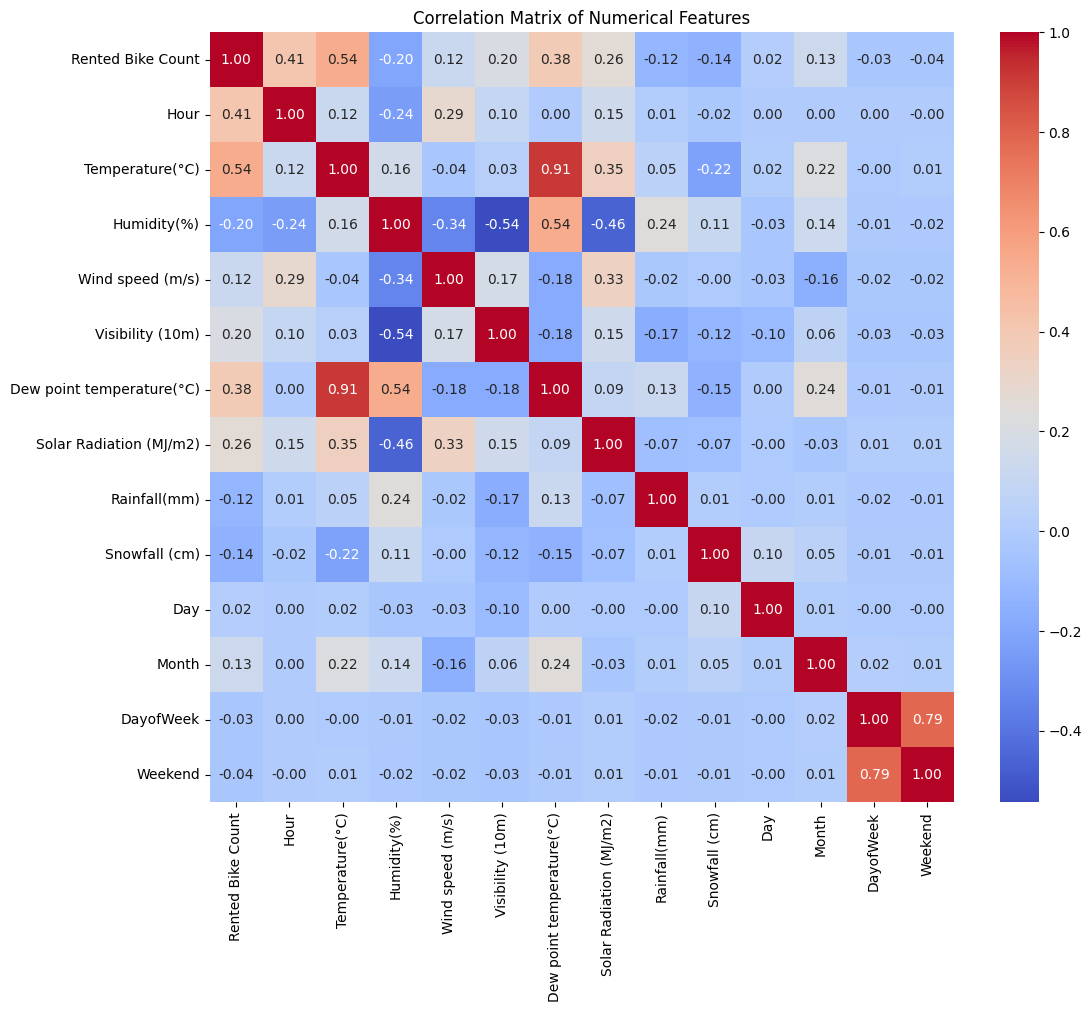

Correlation matrix displayed.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Correlation matrix displayed.")

In [7]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Extract day, month, and day of week
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayofWeek'] = df['Date'].dt.dayofweek

# Extract weekdays/weekend (0 for weekday, 1 for weekend)
df['Weekend'] = ((df['DayofWeek'] == 5) | (df['DayofWeek'] == 6)).astype(int)

print("Date features extracted. Displaying the first 5 rows with new columns:")
display(df.head())

Date features extracted. Displaying the first 5 rows with new columns:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,DayofWeek,Weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,4,0


### Distribution Plot of Rented Bike Count

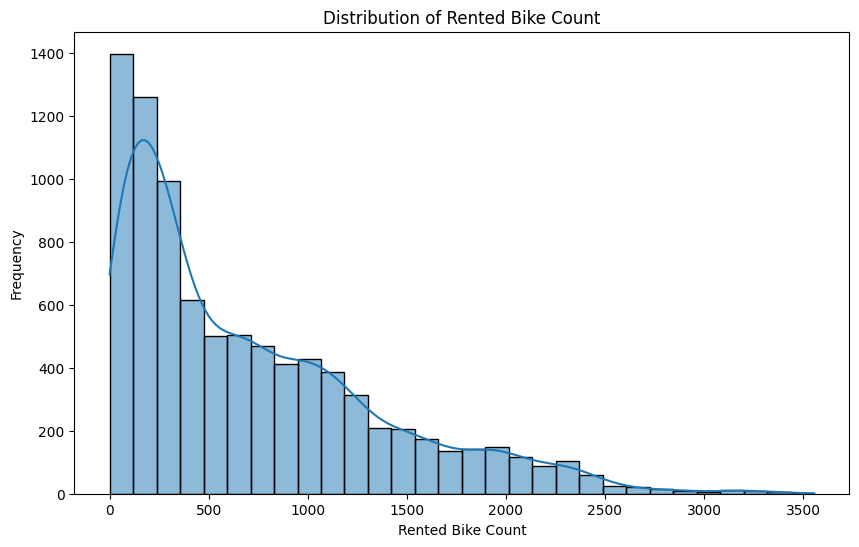

Distribution plot of Rented Bike Count displayed.


In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rented Bike Count'], kde=True, bins=30)
plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.show()
print("Distribution plot of Rented Bike Count displayed.")

### Histogram of All Numerical Features

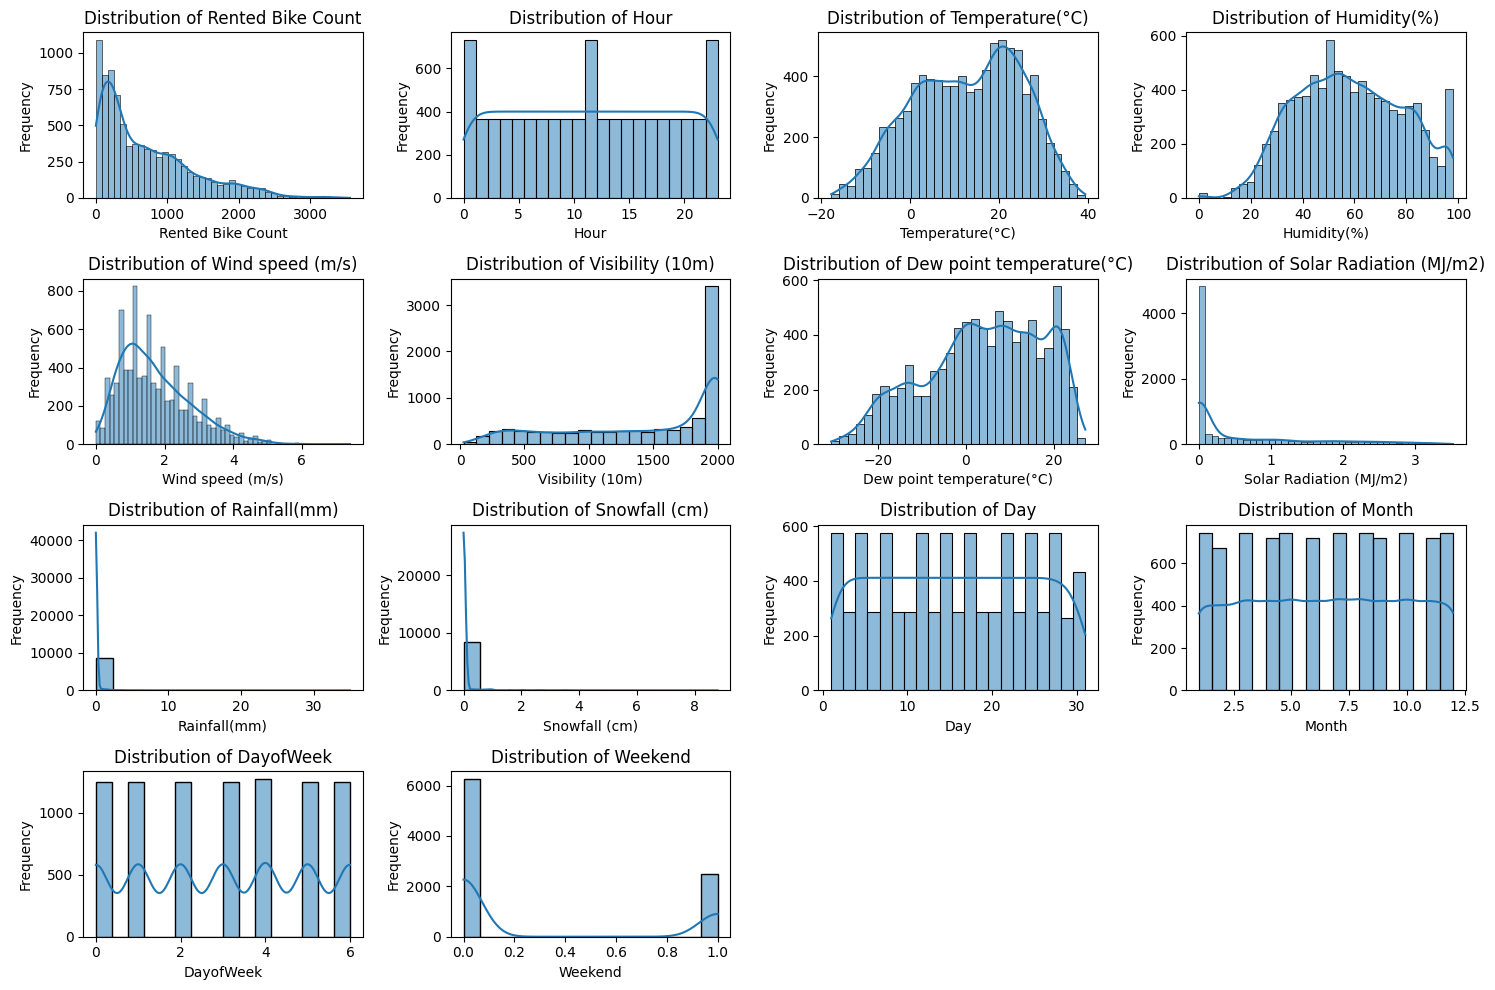

Histograms for all numerical features displayed.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Histograms for all numerical features displayed.")

### Box Plots of Rented Bike Count against Categorical Features

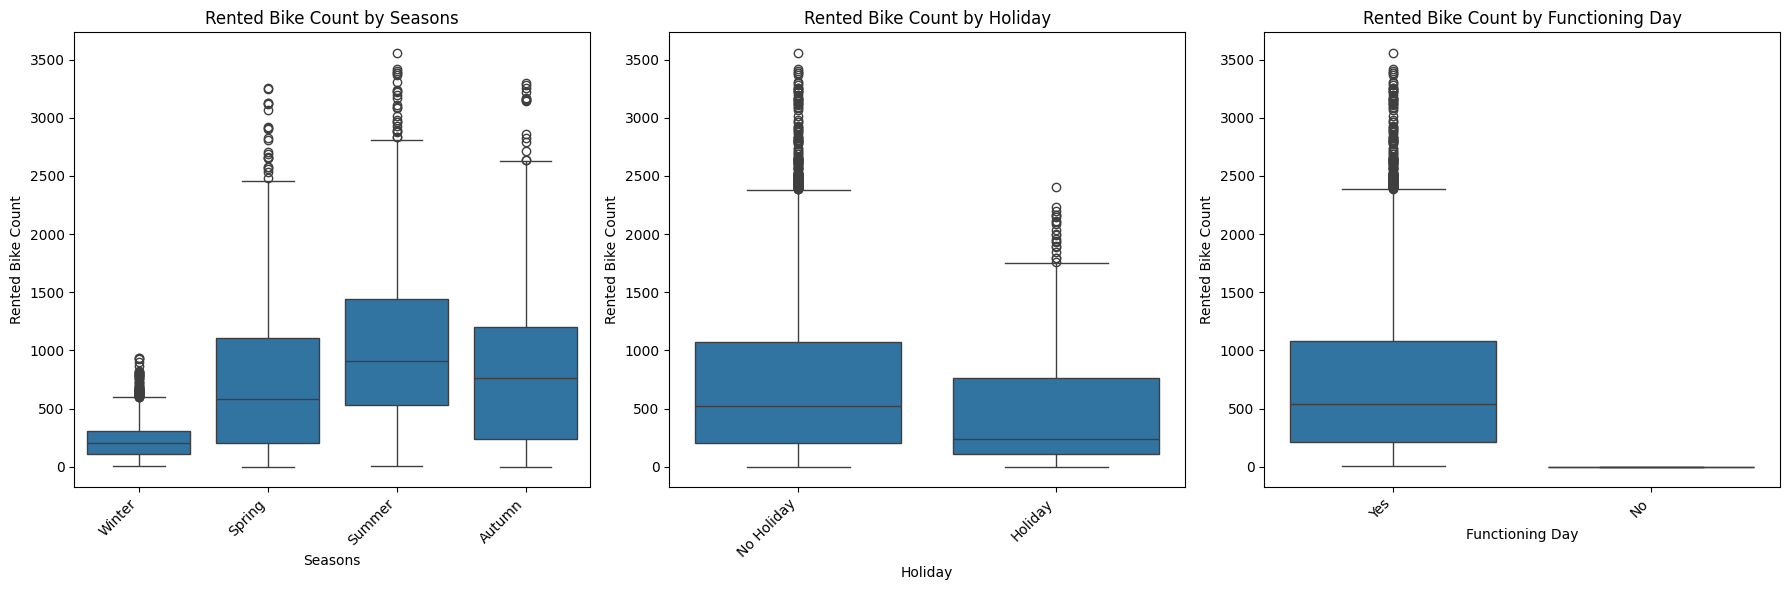

Box plots for Rented Bike Count against categorical features displayed.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Exclude 'Date' if it's still an object type and not relevant for direct box plots
if 'Date' in categorical_cols:
    categorical_cols = categorical_cols.drop('Date')

# Adjust subplot grid based on the number of categorical columns
num_cols = len(categorical_cols)
num_rows = (num_cols + 2) // 3 # Roughly 3 plots per row

plt.figure(figsize=(18, 6 * num_rows))
for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, 3, i + 1) # Create subplot
    sns.boxplot(x=df[col], y=df['Rented Bike Count'])
    plt.title(f'Rented Bike Count by {col}')
    plt.xlabel(col)
    plt.ylabel('Rented Bike Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()
print("Box plots for Rented Bike Count against categorical features displayed.")

### Catplots of Rented Bike Count against various features

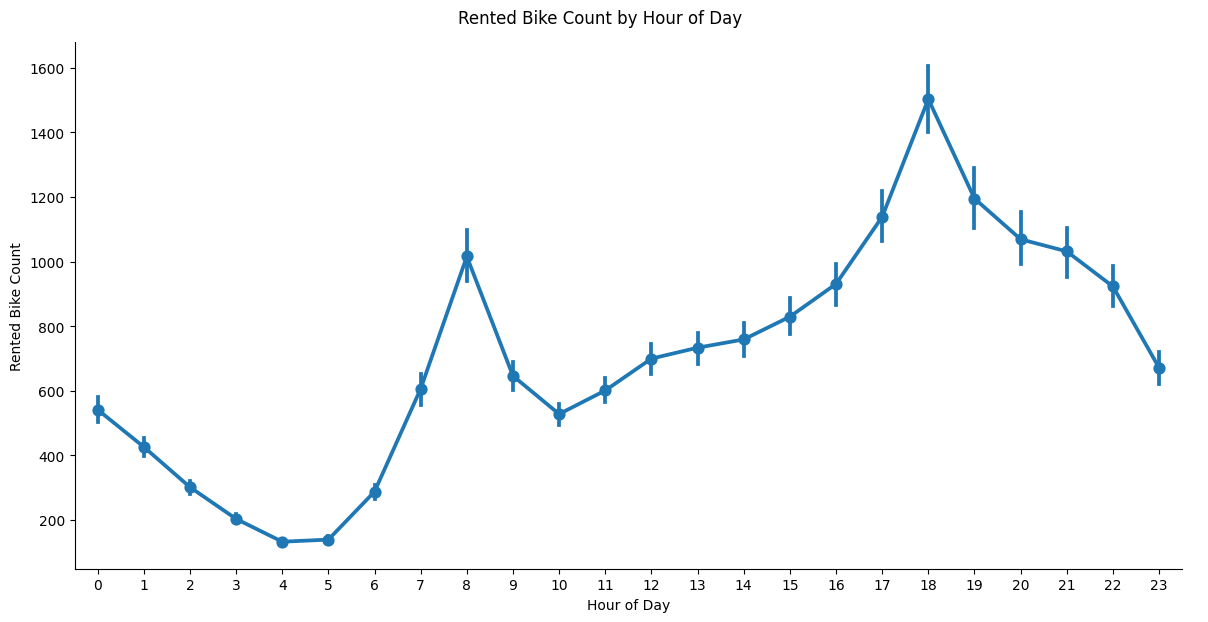

Catplot for Rented Bike Count vs Hour displayed.


In [17]:
# Catplot: Rented Bike Count vs Hour
g = sns.catplot(x='Hour', y='Rented Bike Count', data=df, kind='point', height=6, aspect=2)
g.set_axis_labels("Hour of Day", "Rented Bike Count")
g.fig.suptitle('Rented Bike Count by Hour of Day', y=1.03)
plt.show()
print("Catplot for Rented Bike Count vs Hour displayed.")

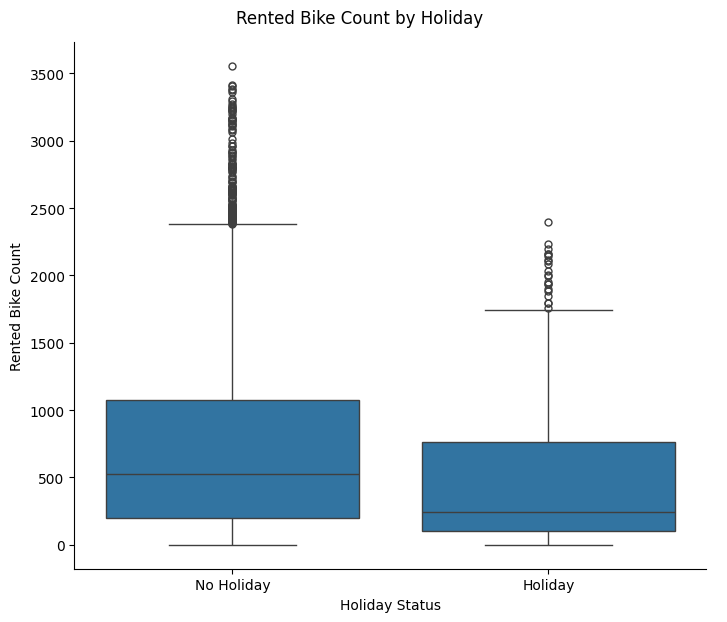

Catplot for Rented Bike Count vs Holiday displayed.


In [18]:
# Catplot: Rented Bike Count vs Holiday
g = sns.catplot(x='Holiday', y='Rented Bike Count', data=df, kind='box', height=6, aspect=1.2)
g.set_axis_labels("Holiday Status", "Rented Bike Count")
g.fig.suptitle('Rented Bike Count by Holiday', y=1.03)
plt.show()
print("Catplot for Rented Bike Count vs Holiday displayed.")

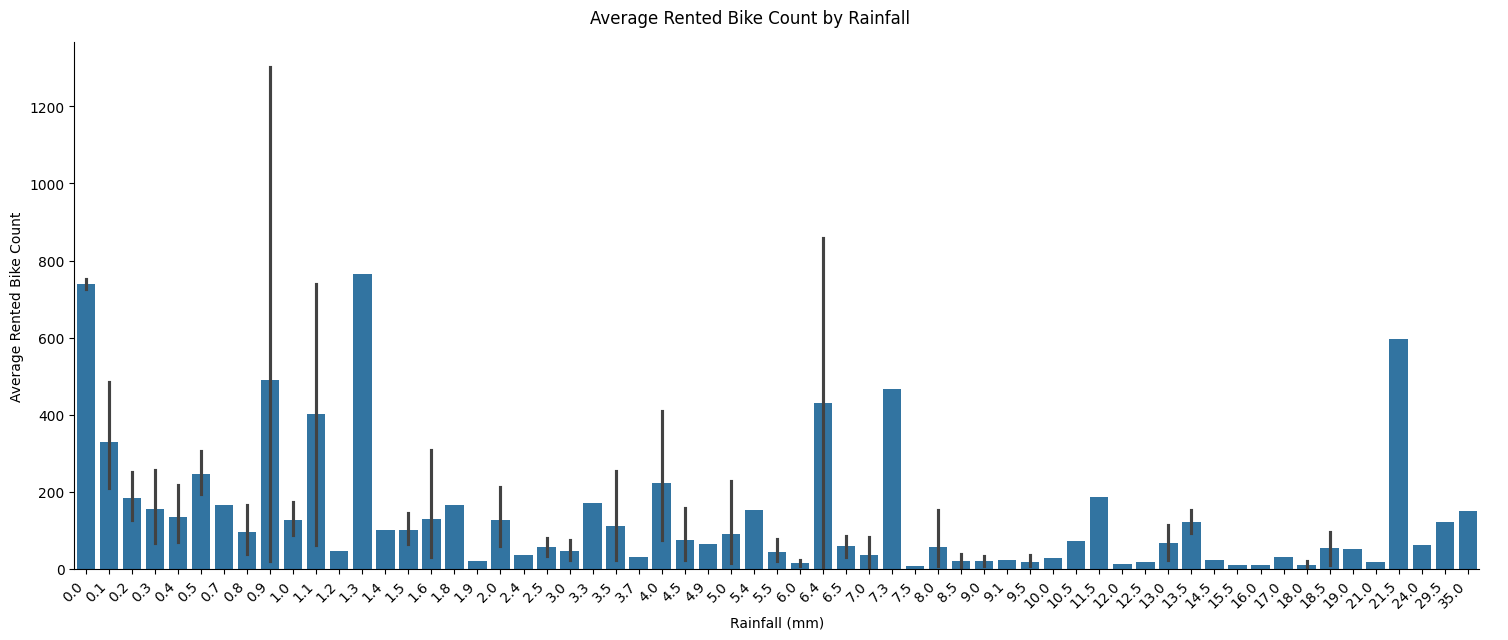

Catplot for Rented Bike Count vs Rainfall(mm) displayed.


In [19]:
# Catplot: Rented Bike Count vs Rainfall(mm)
# Using kind='bar' to show the average rented bike count for each rainfall level
g = sns.catplot(x='Rainfall(mm)', y='Rented Bike Count', data=df, kind='bar', height=6, aspect=2.5)
g.set_axis_labels("Rainfall (mm)", "Average Rented Bike Count")
g.fig.suptitle('Average Rented Bike Count by Rainfall', y=1.03)
plt.xticks(rotation=45, ha='right')
plt.show()
print("Catplot for Rented Bike Count vs Rainfall(mm) displayed.")

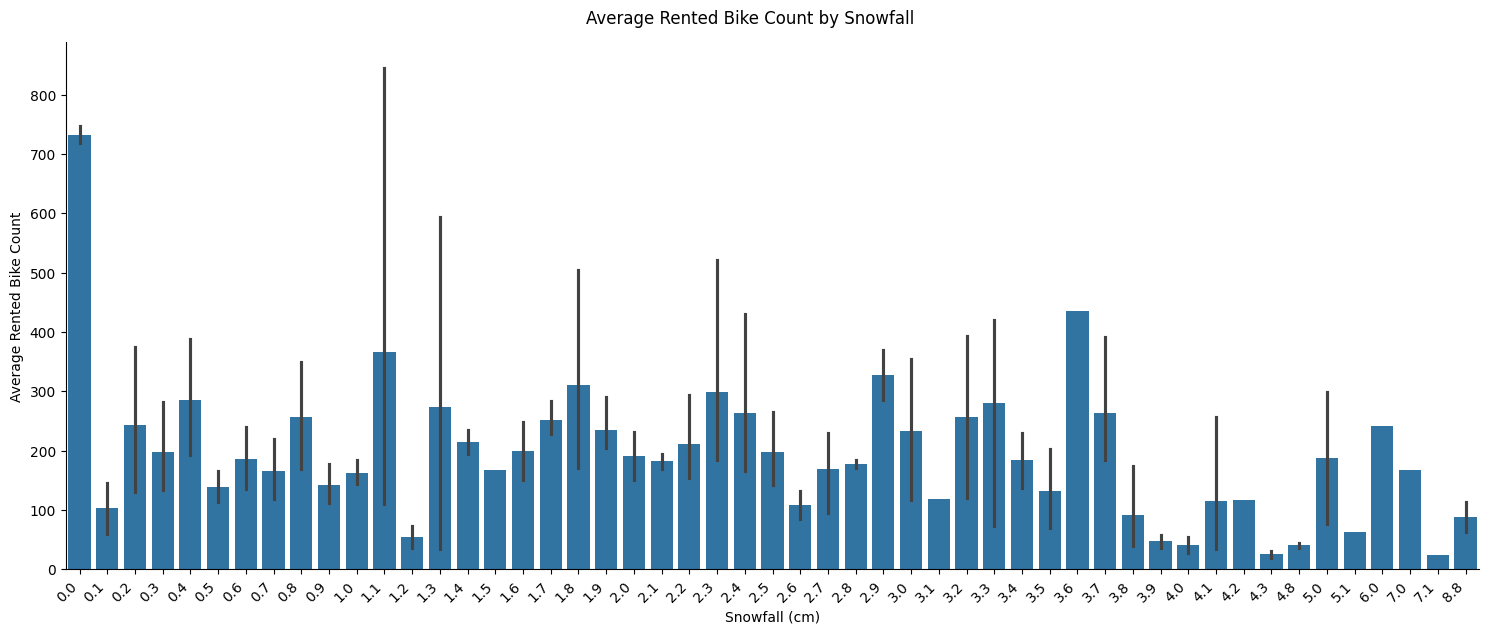

Catplot for Rented Bike Count vs Snowfall (cm) displayed.


In [20]:
# Catplot: Rented Bike Count vs Snowfall (cm)
# Using kind='bar' to show the average rented bike count for each snowfall level
g = sns.catplot(x='Snowfall (cm)', y='Rented Bike Count', data=df, kind='bar', height=6, aspect=2.5)
g.set_axis_labels("Snowfall (cm)", "Average Rented Bike Count")
g.fig.suptitle('Average Rented Bike Count by Snowfall', y=1.03)
plt.xticks(rotation=45, ha='right')
plt.show()
print("Catplot for Rented Bike Count vs Snowfall (cm) displayed.")

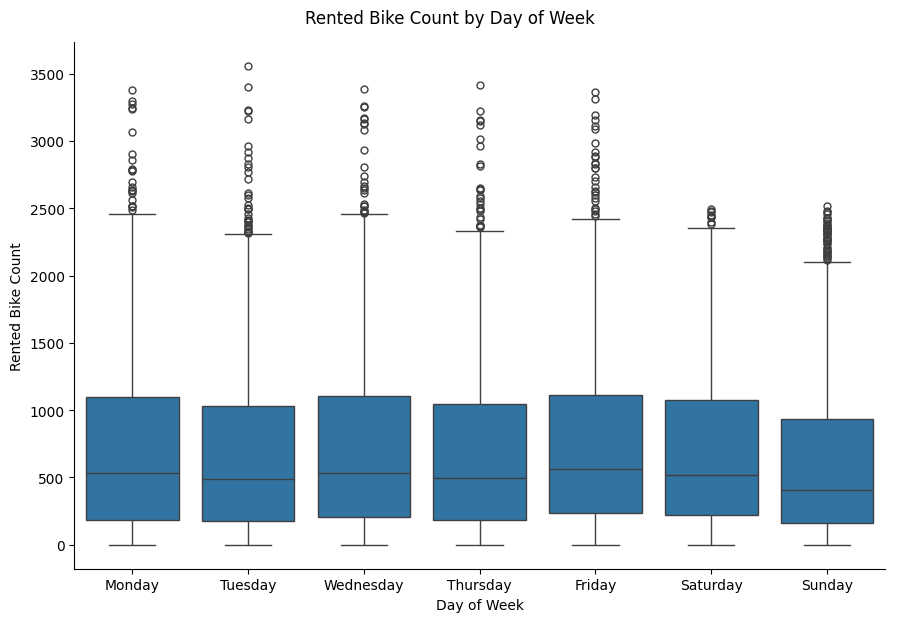

Catplot for Rented Bike Count vs Day of Week displayed.


In [21]:
# Catplot: Rented Bike Count vs DayofWeek (weekdays)
# Map numerical day of week to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayofWeek_Name'] = df['DayofWeek'].map(lambda x: day_names[x])

g = sns.catplot(x='DayofWeek_Name', y='Rented Bike Count', data=df, kind='box', height=6, aspect=1.5,
                order=day_names) # Ensure correct order of days
g.set_axis_labels("Day of Week", "Rented Bike Count")
g.fig.suptitle('Rented Bike Count by Day of Week', y=1.03)
plt.show()
print("Catplot for Rented Bike Count vs Day of Week displayed.")

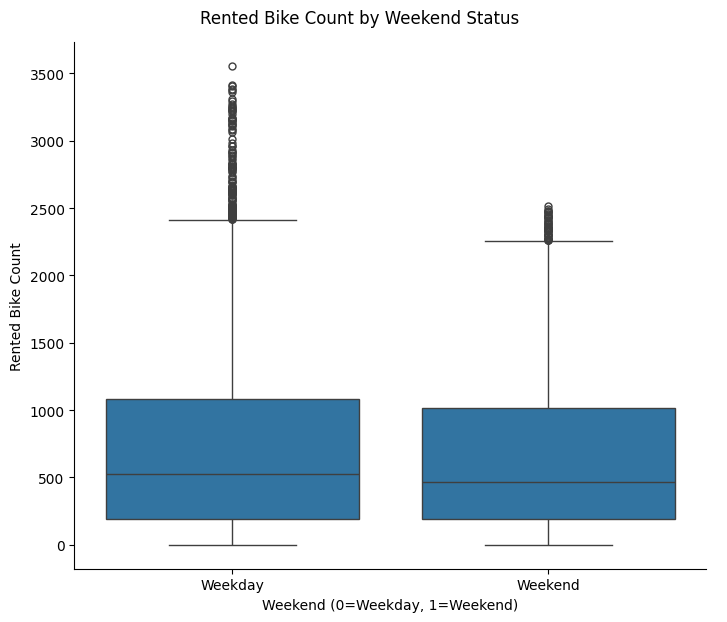

Catplot for Rented Bike Count vs Weekend displayed.


In [22]:
# Catplot: Rented Bike Count vs Weekend
g = sns.catplot(x='Weekend', y='Rented Bike Count', data=df, kind='box', height=6, aspect=1.2)
g.set_axis_labels("Weekend (0=Weekday, 1=Weekend)", "Rented Bike Count")
g.fig.suptitle('Rented Bike Count by Weekend Status', y=1.03)
plt.xticks(ticks=[0, 1], labels=['Weekday', 'Weekend'])
plt.show()
print("Catplot for Rented Bike Count vs Weekend displayed.")

### Inferences from Catplots

After reviewing the catplots, we can observe the following:

- **Rented Bike Count by Hour:** There is a clear pattern in bike rentals throughout the day, typically peaking during morning and evening commute hours and dipping during the night.
- **Rented Bike Count by Holiday:** Bike rental counts might differ significantly on holidays compared to non-holidays. Box plots would show the distribution differences.
- **Average Rented Bike Count by Rainfall (mm):** Generally, as rainfall increases, the average number of rented bikes tends to decrease, indicating that rain discourages bike usage.
- **Average Rented Bike Count by Snowfall (cm):** Similar to rainfall, snowfall also likely has a negative impact on bike rentals, with higher snowfall amounts leading to fewer rentals.
- **Rented Bike Count by Day of Week:** There might be variations in bike rentals across different days of the week, with weekdays potentially showing higher commute-related usage and weekends potentially showing more leisure-related usage.
- **Rented Bike Count by Weekend Status:** Comparing weekdays and weekends directly will show overall differences in rental activity.

### Encoding Categorical Features

In [23]:
import pandas as pd

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Exclude 'Date' and 'DayofWeek_Name' from one-hot encoding as they are already handled or not needed
categorical_cols = categorical_cols.drop(['Date', 'DayofWeek_Name'], errors='ignore')

print(f"Categorical columns to encode: {list(categorical_cols)}")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features encoded. Displaying the first 5 rows of the new DataFrame:")
display(df_encoded.head())

Categorical columns to encode: ['Seasons', 'Holiday', 'Functioning Day']
Categorical features encoded. Displaying the first 5 rows of the new DataFrame:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),...,Day,Month,DayofWeek,Weekend,DayofWeek_Name,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,1,12,4,0,Friday,False,False,True,True,True
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,1,12,4,0,Friday,False,False,True,True,True
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,1,12,4,0,Friday,False,False,True,True,True
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,1,12,4,0,Friday,False,False,True,True,True
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,1,12,4,0,Friday,False,False,True,True,True


### Splitting Data and Scaling Numerical Features

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop 'Date' and 'DayofWeek_Name' columns as they are not needed for modeling after feature extraction/encoding
df_model = df_encoded.drop(columns=['Date', 'DayofWeek_Name'], errors='ignore')

# Identify target variable and features
X = df_model.drop('Rented Bike Count', axis=1)
y = df_model['Rented Bike Count']

# Split the dataset into training and testing sets (80:20 split, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identify numerical columns for scaling (exclude one-hot encoded columns and target)
numerical_cols_to_scale = X_train.select_dtypes(include=['number']).columns.tolist()

# Exclude binary one-hot encoded columns from scaling, if any were explicitly added by get_dummies
# We'll assume any 'object' or 'category' columns were handled by get_dummies and converted to numbers
# For simplicity, we'll scale all remaining numerical columns. If specific columns should be excluded,
# such as 'Hour', 'Day', 'Month', 'DayofWeek', 'Weekend' if they are treated as discrete categories and not continuous,
# that would be a further refinement. For now, we scale all 'number' dtypes.

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in the training set
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Apply scaling to numerical features in the test set using the scaler fitted on the training set
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in training and testing sets scaled.")
print("Displaying the first 5 rows of scaled X_train:")
display(X_train.head())

Dataset split into training and testing sets.
X_train shape: (7008, 18)
X_test shape: (1752, 18)
y_train shape: (7008,)
y_test shape: (1752,)
Numerical features in training and testing sets scaled.
Displaying the first 5 rows of scaled X_train:


,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,DayofWeek,Weekend,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
54,-0.792856,-0.784172,1.358158,0.753381,-1.913976,-0.217364,-0.653917,0.716060,-0.175404,-1.442931,1.582708,1.501285,1.589072,False,False,True,True,True
5748,0.072459,1.725926,0.180877,0.176197,-1.020713,1.614496,0.907070,-0.129173,-0.175404,1.396514,0.136566,1.001285,1.589072,False,True,False,True,True
8382,-0.792856,-0.659498,0.867624,-0.593382,-1.053674,-0.232566,-0.653917,-0.129173,-0.175404,-0.079997,1.293480,0.001284,-0.629298,False,False,False,True,True
4228,-1.081295,0.163348,0.720464,-1.170566,-0.733945,0.443930,-0.653917,-0.129173,-0.175404,1.169359,-0.441890,1.001285,1.589072,True,False,False,True,True
7437,1.370433,0.470877,0.965731,-1.555356,0.924030,0.793579,-0.653917,-0.129173,-0.175404,-1.102197,1.004252,1.001285,1.589072,False,False,False,True,True


### Training and Evaluating Regression Models

In [25]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize models
linear_model = LinearRegression()
lasso_model = Lasso(random_state=1)
ridge_model = Ridge(random_state=1)

# Dictionary to store models and their results
models = {
    'Linear Regression': linear_model,
    'Lasso Regression': lasso_model,
    'Ridge Regression': ridge_model
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"{name} Evaluation:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

print("\n--- Model Comparison ---")
for name, metrics in results.items():
    print(f"{name}: R2={metrics['R2']:.2f}, RMSE={metrics['RMSE']:.2f}")


Training Linear Regression...
Linear Regression Evaluation:
  Mean Squared Error (MSE): 185512.59
  Root Mean Squared Error (RMSE): 430.71
  R-squared (R2): 0.55

Training Lasso Regression...
Lasso Regression Evaluation:
  Mean Squared Error (MSE): 185548.87
  Root Mean Squared Error (RMSE): 430.75
  R-squared (R2): 0.55

Training Ridge Regression...
Ridge Regression Evaluation:
  Mean Squared Error (MSE): 185508.61
  Root Mean Squared Error (RMSE): 430.71
  R-squared (R2): 0.55

--- Model Comparison ---
Linear Regression: R2=0.55, RMSE=430.71
Lasso Regression: R2=0.55, RMSE=430.75
Ridge Regression: R2=0.55, RMSE=430.71


### Splitting Data and Scaling Numerical Features

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop 'Date' and 'DayofWeek_Name' columns as they are not needed for modeling after feature extraction/encoding
df_model = df_encoded.drop(columns=['Date', 'DayofWeek_Name'], errors='ignore')

# Identify target variable and features
X = df_model.drop('Rented Bike Count', axis=1)
y = df_model['Rented Bike Count']

# Split the dataset into training and testing sets (80:20 split, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identify numerical columns for scaling (exclude one-hot encoded columns and target)
numerical_cols_to_scale = X_train.select_dtypes(include=['number']).columns.tolist()

# Exclude binary one-hot encoded columns from scaling, if any were explicitly added by get_dummies
# We'll assume any 'object' or 'category' columns were handled by get_dummies and converted to numbers
# For simplicity, we'll scale all remaining numerical columns. If specific columns should be excluded,
# such as 'Hour', 'Day', 'Month', 'DayofWeek', 'Weekend' if they are treated as discrete categories and not continuous,
# that would be a further refinement. For now, we scale all 'number' dtypes.

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in the training set
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Apply scaling to numerical features in the test set using the scaler fitted on the training set
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in training and testing sets scaled.")
print("Displaying the first 5 rows of scaled X_train:")
display(X_train.head())

Dataset split into training and testing sets.
X_train shape: (7008, 18)
X_test shape: (1752, 18)
y_train shape: (7008,)
y_test shape: (1752,)
Numerical features in training and testing sets scaled.
Displaying the first 5 rows of scaled X_train:


,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,DayofWeek,Weekend,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
54,-0.792856,-0.784172,1.358158,0.753381,-1.913976,-0.217364,-0.653917,0.716060,-0.175404,-1.442931,1.582708,1.501285,1.589072,False,False,True,True,True
5748,0.072459,1.725926,0.180877,0.176197,-1.020713,1.614496,0.907070,-0.129173,-0.175404,1.396514,0.136566,1.001285,1.589072,False,True,False,True,True
8382,-0.792856,-0.659498,0.867624,-0.593382,-1.053674,-0.232566,-0.653917,-0.129173,-0.175404,-0.079997,1.293480,0.001284,-0.629298,False,False,False,True,True
4228,-1.081295,0.163348,0.720464,-1.170566,-0.733945,0.443930,-0.653917,-0.129173,-0.175404,1.169359,-0.441890,1.001285,1.589072,True,False,False,True,True
7437,1.370433,0.470877,0.965731,-1.555356,0.924030,0.793579,-0.653917,-0.129173,-0.175404,-1.102197,1.004252,1.001285,1.589072,False,False,False,True,True


### Training and Evaluating Regression Models

In [27]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize models
linear_model = LinearRegression()
lasso_model = Lasso(random_state=1)
ridge_model = Ridge(random_state=1)

# Dictionary to store models and their results
models = {
    'Linear Regression': linear_model,
    'Lasso Regression': lasso_model,
    'Ridge Regression': ridge_model
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"{name} Evaluation:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

print("\n--- Model Comparison ---")
for name, metrics in results.items():
    print(f"{name}: R2={metrics['R2']:.2f}, RMSE={metrics['RMSE']:.2f}")


Training Linear Regression...
Linear Regression Evaluation:
  Mean Squared Error (MSE): 185512.59
  Root Mean Squared Error (RMSE): 430.71
  R-squared (R2): 0.55

Training Lasso Regression...
Lasso Regression Evaluation:
  Mean Squared Error (MSE): 185548.87
  Root Mean Squared Error (RMSE): 430.75
  R-squared (R2): 0.55

Training Ridge Regression...
Ridge Regression Evaluation:
  Mean Squared Error (MSE): 185508.61
  Root Mean Squared Error (RMSE): 430.71
  R-squared (R2): 0.55

--- Model Comparison ---
Linear Regression: R2=0.55, RMSE=430.71
Lasso Regression: R2=0.55, RMSE=430.75
Ridge Regression: R2=0.55, RMSE=430.71


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop 'Date' and 'DayofWeek_Name' columns as they are not needed for modeling after feature extraction/encoding
df_model = df_encoded.drop(columns=['Date', 'DayofWeek_Name'], errors='ignore')

# Identify target variable and features
X = df_model.drop('Rented Bike Count', axis=1)
y = df_model['Rented Bike Count']

# Split the dataset into training and testing sets (80:20 split, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identify numerical columns for scaling (exclude one-hot encoded columns and target)
numerical_cols_to_scale = X_train.select_dtypes(include=['number']).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in the training set
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])


Dataset split into training and testing sets.
X_train shape: (7008, 18)
X_test shape: (1752, 18)
y_train shape: (7008,)
y_test shape: (1752,)
